# MCDI500 — Programación para la ciencia de datos
## Proyecto Transversal — Fase 2: Limpieza y Transformación

**Título del proyecto:** Factores socioeconómicos y de preparación previa asociados al rendimiento académico

| Campo | Detalle |
|---|---|
| **Curso** | MCDI500 — Programación para la ciencia de datos|
| **Docente** | Omar Salinas Silva |
| **Grupo** | Grupo 7 |
| **Integrantes** | Juan de Dios Díaz Ríos · Francisco Fariña Molina · Constanza Moreno Giacometto · Yenne Sepúlveda Jerez |
| **Fecha** | Junio 2026 |
| **Dataset** | Student Performance Dataset (Cortez & Silva, 2008) — UCI Machine Learning Repository |

---
## Índice
1. [Carga del dataset](#1)
2. [Exploración inicial](#2)
3. [Limpieza de datos](#3)
4. [Transformación de variables](#4)
5. [Validación Dataset](#5)
6. [Resumen del pipeline](#6)
7. [Referencias](#7)
8. [Anexo](#8)

<a id='1'></a>
## 1. Carga del dataset

Se cargan los archivos originales desde `data/raw/` utilizando la función `cargar_dataset()`. El separador del CSV es punto y coma (`;`), conforme al formato del dataset UCI.

**Principio fundamental:** los datos crudos en `data/raw/` **nunca se modifican**. Todas las transformaciones se aplican sobre copias de trabajo.

In [1]:
import sys
import os
sys.path.append(os.path.abspath("../src"))


from functions import *
from librerias import * #pd para pandas y np para numpy

import importlib
 
#importlib.reload(functions)

RUTA_MAT = "../data/raw/student-mat.csv"
RUTA_POR = "../data/raw/student-por.csv"

# Carga de datos
df_mat = cargar_dataset(RUTA_MAT)
df_por = cargar_dataset(RUTA_POR)

print("Dataset cargado exitosamente.")
print(f"  student-mat.csv : {df_mat.shape[0]} filas × {df_mat.shape[1]} columnas")
print(f"  student-por.csv : {df_por.shape[0]} filas × {df_por.shape[1]} columnas")

Dataset cargado exitosamente.
  student-mat.csv : 395 filas × 33 columnas
  student-por.csv : 649 filas × 33 columnas


---
<a id='2'></a>
## 2. Exploración inicial

Antes de cualquier transformación se realiza un diagnóstico completo del dataset. Esta etapa es obligatoria porque permite **tomar decisiones informadas** sobre qué limpiar, qué transformar y qué conservar.

La exploración cubre:
- Estructura general y tipos de datos
- Detección de valores nulos y filas duplicadas
- Validación de rangos según el diccionario de datos
- Detección de outliers con el método IQR
- Análisis de variables categóricas
- Análisis de la variable objetivo G3

In [2]:
##Llamada a función para mostrar las primeras filas de los datasets
print("Primeras filas del dataset de Matemáticas:")
mostrar_primeras_filas(df_mat,10)




Primeras filas del dataset de Matemáticas:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [3]:
print("Primeras filas del dataset de Portugués:")
mostrar_primeras_filas(df_por,10)

Primeras filas del dataset de Portugués:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,12,12,13
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,13,12,13
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,15,16,17
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,12,12,13


In [4]:
# Llamada a funcion para ver cantidad de filas, columnas, duplicados, valores null y tipos de datos
resumen_dataset(df_mat, nombre="Dataset Matemáticas")
resumen_dataset(df_por, nombre="Dataset Portugués")

RESUMEN: Dataset Matemáticas
Filas: 395
Columnas: 33
Duplicados: 0
Valores nulos: 0

Tipos de datos:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object
RESUMEN: Dataset Portugués
Filas: 649
Columnas: 33
Duplicados: 0
Valores nulos: 0

Tipos de datos:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu  

#### Segun lo anterior no se aplicara ningun tratado de datos en cuanto a valores duplicados ni nulos, ya que ambos dataset no presentan estas incidencias.

In [5]:
# Estadísticos descriptivos de variables numéricas
print("=== Estadísticos descriptivos — Matemáticas ===")
df_mat.describe().round(2)

=== Estadísticos descriptivos — Matemáticas ===


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00
mean,16.70,2.75,2.52,1.45,2.04,0.33,3.94,3.24,3.11,1.48,2.29,3.55,5.71,10.91,10.71,10.42
std,1.28,1.09,1.09,0.70,0.84,0.74,0.90,1.00,1.11,0.89,1.29,1.39,8.00,3.32,3.76,4.58
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,3.00,0.00,0.00
25%,16.00,2.00,2.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,8.00,9.00,8.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,4.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,8.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00


In [6]:
# Estadísticos descriptivos de variables numéricas
print("=== Estadísticos descriptivos — Portugues ===")
df_por.describe().round(2)

=== Estadísticos descriptivos — Portugues ===


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00
mean,16.74,2.51,2.31,1.57,1.93,0.22,3.93,3.18,3.18,1.50,2.28,3.54,3.66,11.40,11.57,11.91
std,1.22,1.13,1.10,0.75,0.83,0.59,0.96,1.05,1.18,0.92,1.28,1.45,4.64,2.75,2.91,3.23
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,1.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,2.00,0.00,10.00,10.00,10.00
50%,17.00,2.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,12.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,32.00,19.00,19.00,19.00


In [7]:
#### A continuación se validarn rangos de datos numéricos.

In [8]:

##Llamada a función para validar rangos de datos numericos 

vr_mat = validar_rangos(df_mat, "Matemáticas")
vr_por = validar_rangos(df_por, "Portugués")
#print("\n✓ Todos los valores numéricos están dentro del rango válido.")


  VALIDACIÓN DE RANGOS — Matemáticas
  ✓ age          [15,22]  fuera de rango: 0
  ✓ Medu         [ 0, 4]  fuera de rango: 0
  ✓ Fedu         [ 0, 4]  fuera de rango: 0
  ✓ traveltime   [ 1, 4]  fuera de rango: 0
  ✓ studytime    [ 1, 4]  fuera de rango: 0
  ✓ failures     [ 0, 3]  fuera de rango: 0
  ✓ famrel       [ 1, 5]  fuera de rango: 0
  ✓ freetime     [ 1, 5]  fuera de rango: 0
  ✓ goout        [ 1, 5]  fuera de rango: 0
  ✓ Dalc         [ 1, 5]  fuera de rango: 0
  ✓ Walc         [ 1, 5]  fuera de rango: 0
  ✓ health       [ 1, 5]  fuera de rango: 0
  ✓ absences     [ 0,93]  fuera de rango: 0
  ✓ G1           [ 0,20]  fuera de rango: 0
  ✓ G2           [ 0,20]  fuera de rango: 0
  ✓ G3           [ 0,20]  fuera de rango: 0

  VALIDACIÓN DE RANGOS — Portugués
  ✓ age          [15,22]  fuera de rango: 0
  ✓ Medu         [ 0, 4]  fuera de rango: 0
  ✓ Fedu         [ 0, 4]  fuera de rango: 0
  ✓ traveltime   [ 1, 4]  fuera de rango: 0
  ✓ studytime    [ 1, 4]  fuera de rango: 0
  

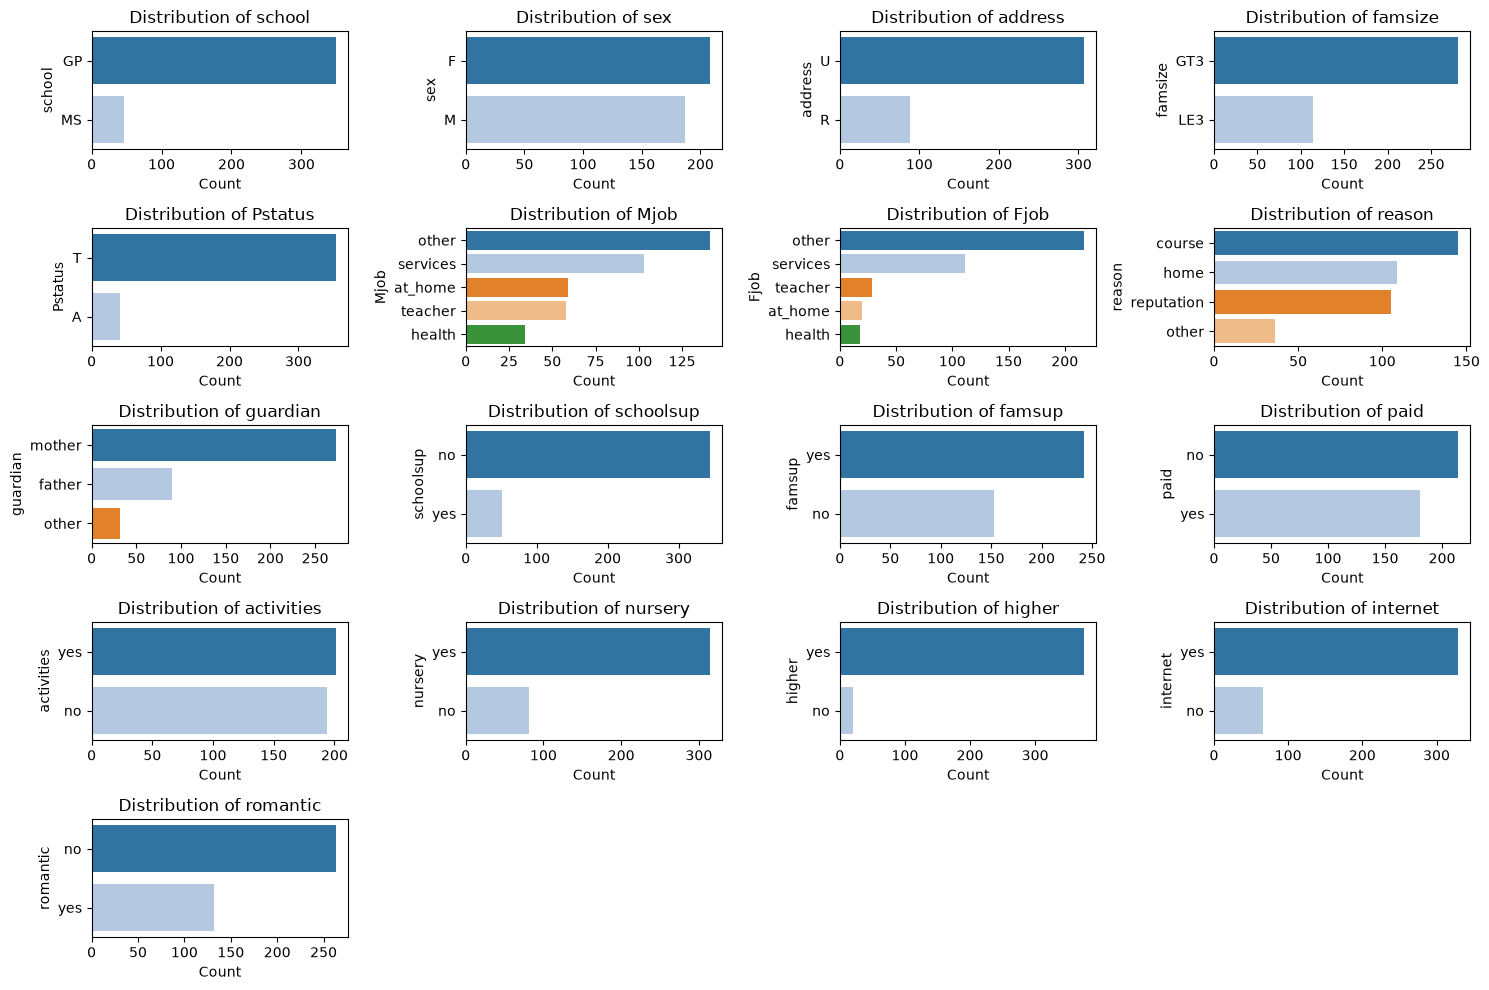

In [9]:
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    counts = df_mat[col].value_counts()
    counts_df = counts.rename_axis(col).reset_index(name='count')
    palette = sns.color_palette('tab20', len(counts_df))

    plt.subplot(5, 4, i+1)
    sns.barplot(x='count', y=col, data=counts_df, hue=col, dodge=False, palette=palette, legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
os.makedirs('../data/development', exist_ok=True)
plt.savefig('../data/development/distribucion_categoricas.png', dpi=100, bbox_inches='tight')
plt.show()

### A continuación se analizan los outliers

In [10]:
vars_continuas = ['age', 'absences', 'G1', 'G2', 'G3']
out_mat = detectar_outliers_iqr(df_mat, vars_continuas, "Matemáticas")
out_por = detectar_outliers_iqr(df_por, vars_continuas, "Portugués")


  DETECCIÓN OUTLIERS (IQR) — Matemáticas
  ⚠ age        Q1=16.0 Q3=18.0 IQR=2.0 límites=[13.0,21.0] outliers=1 (0.3%)
  ⚠ absences   Q1=0.0 Q3=8.0 IQR=8.0 límites=[-12.0,20.0] outliers=15 (3.8%)
  ✓ G1         Q1=8.0 Q3=13.0 IQR=5.0 límites=[0.5,20.5] outliers=0 (0.0%)
  ⚠ G2         Q1=9.0 Q3=13.0 IQR=4.0 límites=[3.0,19.0] outliers=13 (3.3%)
  ✓ G3         Q1=8.0 Q3=14.0 IQR=6.0 límites=[-1.0,23.0] outliers=0 (0.0%)

  DETECCIÓN OUTLIERS (IQR) — Portugués
  ⚠ age        Q1=16.0 Q3=18.0 IQR=2.0 límites=[13.0,21.0] outliers=1 (0.2%)
  ⚠ absences   Q1=0.0 Q3=6.0 IQR=6.0 límites=[-9.0,15.0] outliers=21 (3.2%)
  ⚠ G1         Q1=10.0 Q3=13.0 IQR=3.0 límites=[5.5,17.5] outliers=16 (2.5%)
  ⚠ G2         Q1=10.0 Q3=13.0 IQR=3.0 límites=[5.5,17.5] outliers=25 (3.9%)
  ⚠ G3         Q1=10.0 Q3=14.0 IQR=4.0 límites=[4.0,20.0] outliers=16 (2.5%)


**Interpretación:** La variable `absences` presenta alta asimetría positiva (skewness MAT=3.67, POR=2.02), con valores extremos de hasta 75 ausencias en Matemáticas. Esto justifica un tratamiento específico. El resto de las variables continuas presentan outliers menores dentro de rangos válidos del dominio.

C:\Users\yenne.sepulveda\AppData\Local\Temp\ipykernel_36132\2850280986.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df['absences'], vert=True, patch_artist=True,
C:\Users\yenne.sepulveda\AppData\Local\Temp\ipykernel_36132\2850280986.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df['absences'], vert=True, patch_artist=True,


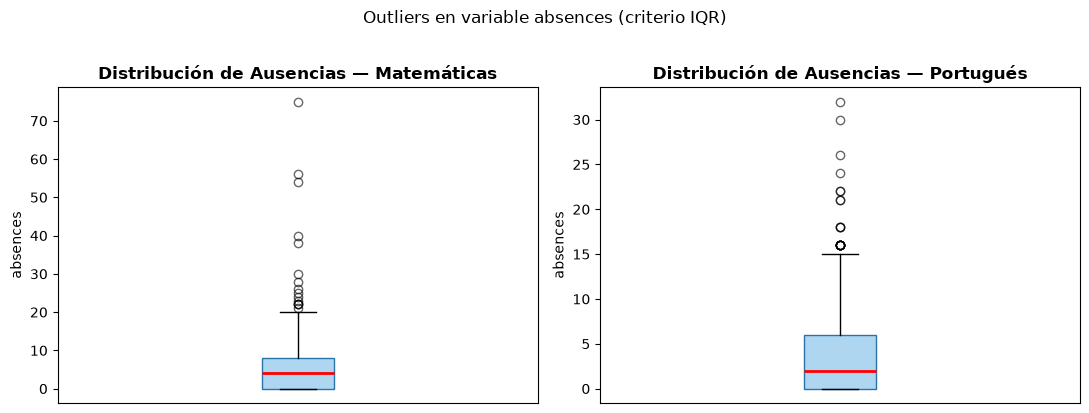

In [26]:
# Visualización de distribución de absences (outliers)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, df, titulo in zip(axes, [df_mat, df_por], ['Matemáticas', 'Portugués']):
    ax.boxplot(df['absences'], vert=True, patch_artist=True,
               boxprops=dict(facecolor='#AED6F1', color='#2874A6'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', color='orange', alpha=0.6))
    ax.set_title(f'Distribución de Ausencias — {titulo}', fontweight='bold')
    ax.set_ylabel('absences'); ax.set_xticks([])
plt.suptitle('Outliers en variable absences (criterio IQR)', y=1.02)
plt.tight_layout()
os.makedirs('../data/development', exist_ok=True)
plt.savefig('../data/development/fig_outliers_absences.png', dpi=100, bbox_inches='tight')
plt.show()

### A continuación se realizan correlaciones de variables


ANÁLISIS DE CORRELACIONES — student-mat.csv (Matemáticas)

Variables numéricas consideradas: 16

Correlaciones con nota final G3:
G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

Figura guardada en: ../data/development/correlacion_matematicas.png


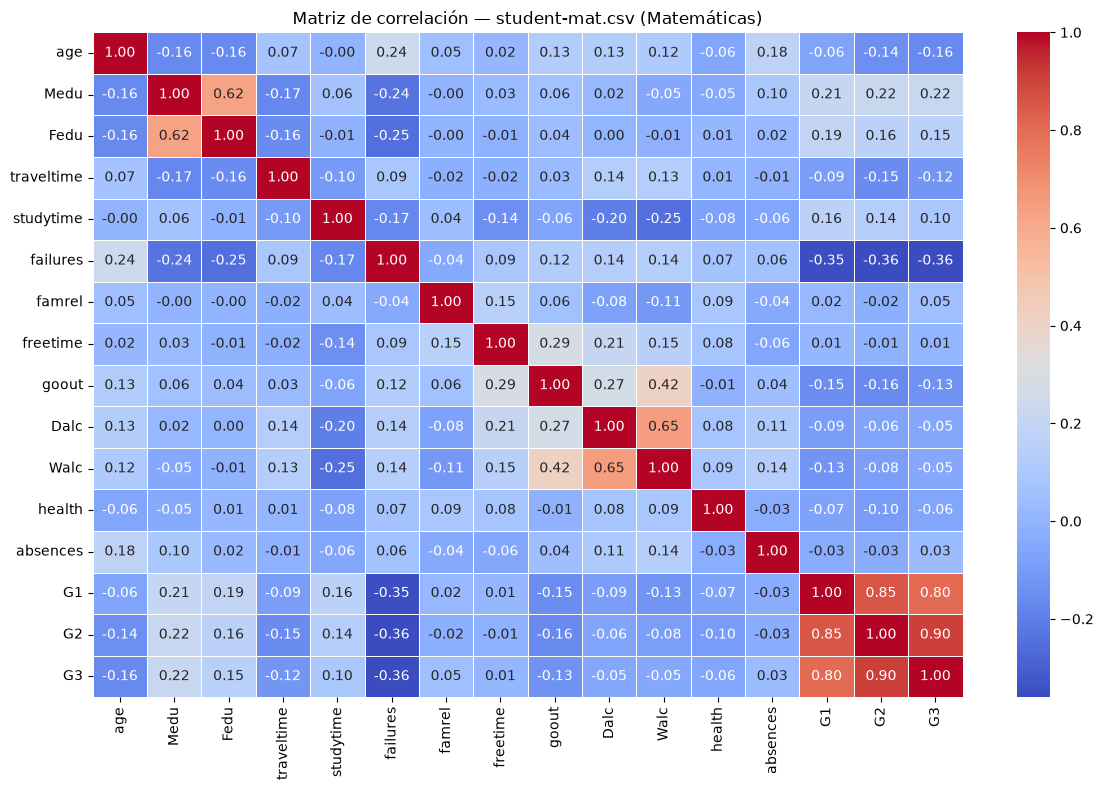

In [12]:
matriz_corr_mat = analizar_correlaciones(
    df_mat,
    nombre_dataset="student-mat.csv (Matemáticas)",
    guardar_figura=True,
    ruta_salida="../data/development/correlacion_matematicas.png"
)
#print(matriz_corr_mat)

### Interpretación de las correlaciones con la nota final de Matemáticas(G3)
 
Los resultados muestran que las variables con mayor relación positiva corresponden a las notas obtenidas en períodos anteriores. En particular, la segunda evaluación (**G2**) presenta la correlación más alta con la nota final (**0.90**), seguida por la primera evaluación (**G1**, con 0.80), lo que indica que el desempeño académico previo constituye un fuerte predictor del rendimiento final.
 
En menor medida, se observan correlaciones positivas débiles con el nivel educativo de la madre (**Medu = 0.22**) y del padre (**Fedu = 0.15**), sugiriendo que un mayor nivel educativo de los padres podría estar asociado con mejores resultados académicos.
 
Asimismo, el tiempo dedicado al estudio (**studytime = 0.10**) y la calidad de las relaciones familiares (**famrel = 0.05**) presentan asociaciones positivas, aunque de baja magnitud. Por otra parte, las ausencias (**absences = 0.03**) muestran una relación prácticamente nula con la nota final.
 
Respecto de las variables relacionadas con hábitos y estilo de vida, se observa una correlación negativa débil entre la frecuencia de salidas con amigos (**goout = -0.13**) y las notas finales. De forma similar, el consumo de alcohol durante la semana (**Dalc = -0.05**) y los fines de semana (**Walc = -0.05**) presenta una asociación negativa de baja intensidad con el rendimiento académico.
 
La edad del estudiante (**age = -0.16**) y el tiempo de desplazamiento al establecimiento (**traveltime = -0.12**) también muestran correlaciones negativas débiles.
 
Finalmente, la variable que presenta la asociación negativa más importante con el rendimiento académico es el número de reprobaciones anteriores (**failures = -0.36**), lo que sugiere que los estudiantes con un mayor historial de asignaturas reprobadas tienden a obtener menores calificaciones finales.
 
En general, los resultados indican que el rendimiento académico está principalmente influenciado por el desempeño previo del estudiante y, en menor medida, por factores familiares y antecedentes académicos, mientras que las variables relacionadas con hábitos personales presentan asociaciones más débiles.


ANÁLISIS DE CORRELACIONES — student-por.csv (Portugués)

Variables numéricas consideradas: 16

Correlaciones con nota final G3:
G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64

Figura guardada en: ../data/development/correlacion_portugues.png


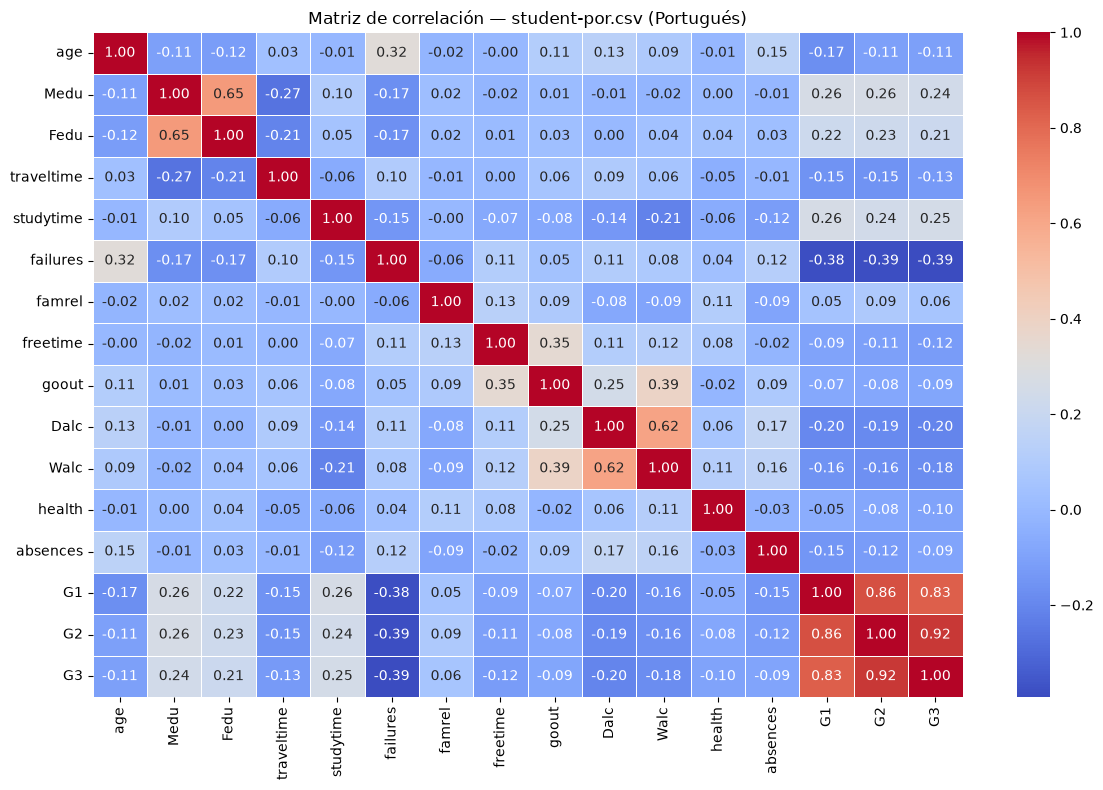

In [13]:
matriz_corr_por = analizar_correlaciones(
    df_por,
    nombre_dataset="student-por.csv (Portugués)", guardar_figura=True,
    ruta_salida="../data/development/correlacion_portugues.png"
)
#print(matriz_corr_por)

### Interpretación de las correlaciones con la nota final de Portugues (G3)
  
Los resultados muestran que las calificaciones obtenidas en evaluaciones anteriores son las variables con mayor asociación positiva con la nota final. En particular, la segunda evaluación (**G2**) presenta una correlación muy fuerte con G3 (**0.92**), seguida por la primera evaluación (**G1 = 0.83**), lo que indica que el desempeño previo del estudiante constituye un importante predictor del rendimiento académico final.
 
Asimismo, el tiempo dedicado al estudio (**studytime = 0.25**) y el nivel educativo de la madre (**Medu = 0.24**) presentan correlaciones positivas débiles a moderadas con la nota final. De manera similar, el nivel educativo del padre (**Fedu = 0.21**) también muestra una asociación positiva, aunque de menor intensidad.
 
Por otra parte, las relaciones familiares (**famrel = 0.06**) presentan una correlación positiva muy débil, mientras que las ausencias (**absences = -0.09**), el estado de salud (**health = -0.09**) y la edad (**age = -0.11**) muestran asociaciones negativas de baja magnitud con el rendimiento académico.
 
Respecto de las variables asociadas a hábitos y tiempo libre, se observa que la frecuencia de salidas con amigos (**goout = -0.09**), el tiempo libre disponible (**freetime = -0.12**) y el tiempo de desplazamiento al establecimiento (**traveltime = -0.12**) presentan correlaciones negativas débiles con la nota final.
 
En cuanto al consumo de alcohol, tanto durante los fines de semana (**Walc = -0.18**) como durante los días laborables (**Dalc = -0.20**) se observa una relación negativa con el rendimiento académico, sugiriendo que mayores niveles de consumo se asocian con menores calificaciones.
 
Finalmente, la variable que presenta la correlación negativa más importante es el número de reprobaciones previas (**failures = -0.39**), lo que indica que los estudiantes con antecedentes de asignaturas reprobadas tienden a obtener peores resultados en la evaluación final.
 
En general, los resultados sugieren que el rendimiento académico en Portugués está principalmente determinado por el desempeño previo del estudiante y por su historial de reprobaciones, mientras que factores relacionados con el entorno familiar y los hábitos personales presentan asociaciones más débiles.

### A continuación se realizara un analisis de la variable objetivo G3

In [14]:
print("\n=== Análisis G3 = 0 ===")
analizar_g3_cero(df_mat, "MAT")
analizar_g3_cero(df_por, "POR")
print("""
→ Decisión: Se CONSERVAN todos los registros G3=0.
  Son valores válidos (rango 0-20). Eliminarlos introduciría sesgo
  al excluir a los estudiantes con peor desempeño.
  Se crea el flag 'desercion' (G2=0 y G3=0) para análisis diferenciado.
""")


=== Análisis G3 = 0 ===
  MAT: G3=0 total=38 | G2=0 y G3=0 (deserción)=13 | G2>0 y G3=0 (reprobado)=25
  POR: G3=0 total=15 | G2=0 y G3=0 (deserción)=7 | G2>0 y G3=0 (reprobado)=8

→ Decisión: Se CONSERVAN todos los registros G3=0.
  Son valores válidos (rango 0-20). Eliminarlos introduciría sesgo
  al excluir a los estudiantes con peor desempeño.
  Se crea el flag 'desercion' (G2=0 y G3=0) para análisis diferenciado.



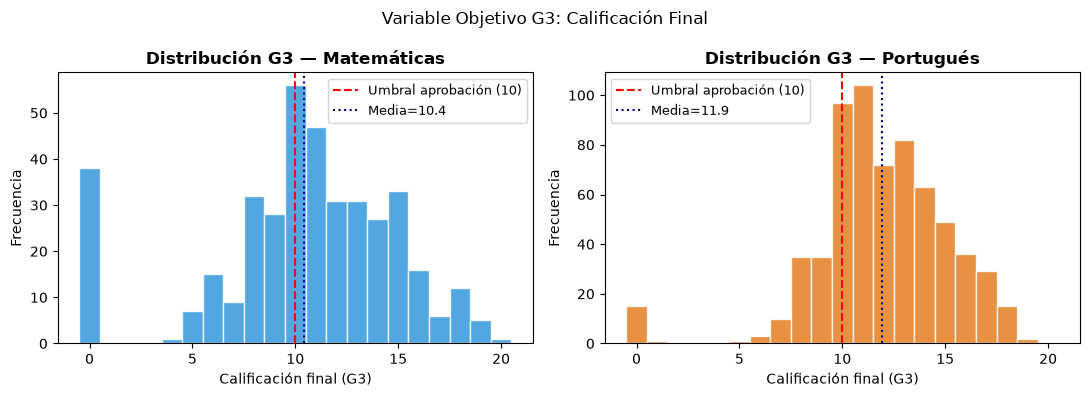

In [15]:
# Distribución de G3 — histograma comparativo
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, df, titulo, color in zip(axes, [df_mat, df_por],
                                  ['Matemáticas', 'Portugués'], ['#3498DB','#E67E22']):
    ax.hist(df['G3'], bins=21, range=(-0.5, 20.5), color=color, edgecolor='white', alpha=0.85)
    ax.axvline(10, color='red', linestyle='--', linewidth=1.5, label='Umbral aprobación (10)')
    ax.axvline(df['G3'].mean(), color='navy', linestyle=':', linewidth=1.5,
               label=f"Media={df['G3'].mean():.1f}")
    ax.set_title(f'Distribución G3 — {titulo}', fontweight='bold')
    ax.set_xlabel('Calificación final (G3)'); ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
plt.suptitle('Variable Objetivo G3: Calificación Final', fontsize=12)
plt.tight_layout()
os.makedirs('../data/processed', exist_ok=True)
plt.savefig('../data/processed/fig_distribucion_g3.png', dpi=100, bbox_inches='tight')
plt.show()

La distribución de las calificaciones finales en Matemáticas se concentra principalmente entre 8 y 14 puntos, con una media de 10,4. La mayoría de los estudiantes supera el umbral de aprobación establecido en 10 puntos.Las calificaciones finales en Portugués presentan una distribución más concentrada en torno a los 12 puntos, con una media de 11,9. En general, se observa un mayor rendimiento y una mayor proporción de estudiantes sobre el umbral de aprobación de 10 puntos.

<a id='3'></a>
## 3. Limpieza de datos

Con base en el diagnóstico, se aplica el pipeline de limpieza. Las decisiones adoptadas son:

| Problema detectado | Decisión | Justificación |
|---|---|---|
| 0 valores nulos | Sin acción | Dataset completo |
| 0 filas duplicadas | Sin acción | Dataset íntegro |
| 0 valores fuera de rango | Sin acción | Todos conformes al diccionario |
| Outliers en `absences` (skew=3.67) | Winsorización p95 | Atenúa extremos, conserva registros |
| G3=0 (deserciones) | Conservar + flag `desercion` | Evita sesgo, permite análisis diferenciado |

---
## Tratamiento de outliers en `absences`
 
Se detectaron valores extremos (hasta 75 ausencias en Matemáticas) con criterio IQR.
Existen 6 posibles opciones:
 
- **Eliminar fila** → pierde toda la información del estudiante (G1/G2/G3 incluidos)
- **Poner NaN** → crea un nulo donde no había, traslada el problema a una imputación posterior
- **Imputar media/mediana** → inventa un dato falso (75 ≠ 4)
- **Transformación logarítmica** → distorsiona la escala de toda la variable, difícil de interpretar
- **Recorte (trimming)** → mismo problema que eliminar filas
- **Winsorización p95 (adoptada)** → cap a 18, conserva la fila completa, sin inventar datos
 
**Decisión del equipo: Winsorización** 
El valor está dentro del rango válido `[0, 93]` — es un comportamiento real, no un error. Por eso se descarta tratarlo como dato erróneo
(eliminar/NaN/imputar) y se opta por **atenuar** en vez de borrar o inventar. El valor
original queda preservado en `absences_original` para trazabilidad completa.

In [16]:
# Aplicar pipeline de limpieza
df_mat_clean = limpiar_dataset(df_mat, 'mat')
df_por_clean = limpiar_dataset(df_por, 'por')

# Winsorización de absences
print("\n  Tratamiento de outliers en absences:")
df_mat_clean = winsorizacion(df_mat_clean, 'absences', 0.95)
df_por_clean = winsorizacion(df_por_clean, 'absences', 0.95)
print("  ✓ Columna 'absences_original' preservada para trazabilidad.")


  Pipeline de limpieza — MAT
  [1] Duplicados eliminados : 0  (ninguno)
  [2] Strip en 17 columnas de texto ✓
  [3] Flag 'desercion' creado: 13 casos
  [4] Columna 'asignatura' = 'mat' ✓
  Resultado: 395 → 395 filas

  Pipeline de limpieza — POR
  [1] Duplicados eliminados : 0  (ninguno)
  [2] Strip en 17 columnas de texto ✓
  [3] Flag 'desercion' creado: 7 casos
  [4] Columna 'asignatura' = 'por' ✓
  Resultado: 649 → 649 filas

  Tratamiento de outliers en absences:
  Winsorización 'absences': cap p95=18 → 20 valores ajustados
  Winsorización 'absences': cap p95=12 → 32 valores ajustados
  ✓ Columna 'absences_original' preservada para trazabilidad.


In [17]:
BASE = "../data/processed/"
print("=== EXPORTACIÓN A data/processed/ ===")
exportar_dataset(df_mat_clean,     BASE + "student_mat_clean.csv",
                 "MAT limpio: flags + winsorización (sin OHE)")
exportar_dataset(df_por_clean,     BASE + "student_por_clean.csv",
                 "POR limpio: flags + winsorización (sin OHE)")

=== EXPORTACIÓN A data/processed/ ===
  ✓ student_mat_clean.csv                       395f ×  36c  (45.6 KB)
    → MAT limpio: flags + winsorización (sin OHE)
  ✓ student_por_clean.csv                       649f ×  36c  (72.8 KB)
    → POR limpio: flags + winsorización (sin OHE)


---
<a id='4'></a>
## 4. Transformación de variables

Las transformaciones preparan los datos para el análisis estadístico y el modelado de Fases 3 y 4:

1. **Codificación binaria:** variables `yes/no` → `1/0`
2. **Codificación de variables binarias propias** (`sex`, `address`, `school`, etc.)
3. **One-Hot Encoding** para variables nominales con más de 2 categorías

> Las transformaciones se aplican sobre una copia `_encoded` para preservar el dataset limpio sin codificar.

In [18]:
# Aplicar transformaciones completas
print("\n=== PIPELINE DE TRANSFORMACIONES ===\n")
print("[Matemáticas]")
df_mat_enc = codificar_binarias(df_mat_clean)
df_mat_enc = codificar_ohe(df_mat_enc)
df_mat_enc = crear_variables_derivadas(df_mat_enc)
print("[Portugués]")
df_por_enc = codificar_binarias(df_por_clean)
df_por_enc = codificar_ohe(df_por_enc)
df_por_enc = crear_variables_derivadas(df_por_enc)


=== PIPELINE DE TRANSFORMACIONES ===

[Matemáticas]
  Codificación binaria: 8 vars yes/no + 5 vars propias
  OHE aplicado en ['Mjob', 'Fjob', 'reason', 'guardian'] → 9 nuevas columnas
  Variables derivadas creadas: ['aprobado', 'progreso_g1_g3', 'nivel_alcohol', 'edu_familiar_media']
[Portugués]
  Codificación binaria: 8 vars yes/no + 5 vars propias
  OHE aplicado en ['Mjob', 'Fjob', 'reason', 'guardian'] → 9 nuevas columnas
  Variables derivadas creadas: ['aprobado', 'progreso_g1_g3', 'nivel_alcohol', 'edu_familiar_media']


In [19]:
mostrar_primeras_filas(df_mat_enc,5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,aprobado,progreso_g1_g3,nivel_alcohol,edu_familiar_media
0,GP,F,18,U,GT3,A,4,4,2,2,...,1,0,0,0,1,0,0,1,1.0,4.0
1,GP,F,17,U,GT3,T,1,1,1,2,...,0,0,0,0,0,0,0,1,1.0,1.0
2,GP,F,15,U,LE3,T,1,1,1,2,...,0,0,1,0,1,0,1,3,2.5,1.0
3,GP,F,15,U,GT3,T,4,2,1,3,...,0,1,0,0,1,0,1,0,1.0,3.0
4,GP,F,16,U,GT3,T,3,3,1,2,...,0,1,0,0,0,0,1,4,1.5,3.0


In [20]:
#llamar a la funcion para exportar datasets limpios y transformados
exportar_dataset(df_mat_enc,     BASE + "student_mat_clean_encode.csv",
                 "MAT limpio + encoded: flags + winsorización + OHE + variables derivadas")
exportar_dataset(df_por_enc,     BASE + "student_por_clean_encode.csv",
                 "POR limpio + encoded: flags + winsorización + OHE + variables derivadas")

  ✓ student_mat_clean_encode.csv                395f ×  54c  (48.5 KB)
    → MAT limpio + encoded: flags + winsorización + OHE + variables derivadas
  ✓ student_por_clean_encode.csv                649f ×  54c  (77.7 KB)
    → POR limpio + encoded: flags + winsorización + OHE + variables derivadas


---
<a id='5'></a>
## 5. Validación Dataset

Se verifica la integridad de los datasets procesados mediante pruebas formales (`assert`) antes de exportar. Esta evidencia visible demuestra que el pipeline no introdujo errores.

In [21]:
print("=" * 55)
print("  VALIDACIÓN POST-PROCESAMIENTO")
print("=" * 55)
ok_mat = validar_dataset_final(df_mat, df_mat_enc, "Matemáticas encoded")
ok_por = validar_dataset_final(df_por, df_por_enc, "Portugués encoded")

if ok_mat and ok_por:
    print("\n✅ Todos los datasets superaron la validación.")
else:
    print("\n❌ Revisar los errores anteriores antes de exportar.")

  VALIDACIÓN POST-PROCESAMIENTO

  Validando: Matemáticas encoded
  ✓ Filas conservadas: 395
  ✓ Sin nulos en columnas originales
  ✓ G1, G2, G3 intactos
  ✓ Flag 'aprobado' coherente (265 aprobados)
  ✓ Flag 'desercion' coherente (13 casos)
  ✓ Sin filas duplicadas
  ✓ G1, G2, G3 en rango [0, 20]
  → VALIDACIÓN EXITOSA ✅

  Validando: Portugués encoded
  ✓ Filas conservadas: 649
  ✓ Sin nulos en columnas originales
  ✓ G1, G2, G3 intactos
  ✓ Flag 'aprobado' coherente (549 aprobados)
  ✓ Flag 'desercion' coherente (7 casos)
  ✓ Sin filas duplicadas
  ✓ G1, G2, G3 en rango [0, 20]
  → VALIDACIÓN EXITOSA ✅

✅ Todos los datasets superaron la validación.


In [22]:
# Evidencia visual: conteos antes y después
print("\n=== EVIDENCIA DE CALIDAD — CONTEOS ===")
for nombre, df_o, df_p in [('MAT', df_mat, df_mat_enc), ('POR', df_por, df_por_enc)]:
    print(f"\n  {nombre}:")
    print(f"    Filas   : {len(df_o)} → {len(df_p)} (delta={len(df_p)-len(df_o)})")
    print(f"    Columnas: {df_o.shape[1]} → {df_p.shape[1]} (+{df_p.shape[1]-df_o.shape[1]} nuevas)")
    print(f"    Nulos   : {df_o.isnull().sum().sum()} → {df_p.isnull().sum().sum()}")
    print(f"    Dupl.   : {df_o.duplicated().sum()} → {df_p.duplicated().sum()}")


=== EVIDENCIA DE CALIDAD — CONTEOS ===

  MAT:
    Filas   : 395 → 395 (delta=0)
    Columnas: 33 → 54 (+21 nuevas)
    Nulos   : 0 → 0
    Dupl.   : 0 → 0

  POR:
    Filas   : 649 → 649 (delta=0)
    Columnas: 33 → 54 (+21 nuevas)
    Nulos   : 0 → 0
    Dupl.   : 0 → 0


### Como la validación del dataset es correcta, se decide como equipo que los archivos finales para la Fase 3 del proyecto seran los siguientes: student_por_clean_encode.csv student_mat_clean_encode.csv


<a id='6'></a>
## 6. Resumen del pipeline



In [23]:
print("=" * 65)
print("  RESUMEN EJECUTIVO — FASE 2: LIMPIEZA Y PREPARACIÓN")
print("=" * 65)
print(f"""
  DATOS ORIGINALES
    student-mat.csv : {df_mat.shape[0]} registros × {df_mat.shape[1]} variables
    student-por.csv : {df_por.shape[0]} registros × {df_por.shape[1]} variables

  HALLAZGOS AUDITORÍA
    ✓  0 valores nulos en ambos datasets
    ✓  0 filas duplicadas en ambos datasets
    ✓  0 valores fuera de rango (todas las variables)
    ✓  0 categorías inesperadas en variables categóricas
    ⚠  absences: skewness MAT=3.67 / POR=2.02 → Winsorización p95 aplicada
    ℹ  G3=0: 38 casos MAT / 15 casos POR → Flag 'desercion' creado

  TRANSFORMACIONES
    + Codificación yes/no → 1/0 (8 variables)
    + Features binarias: sex_F, address_U, famsize_GT3, Pstatus_T, school_GP
    + One-Hot Encoding: Mjob, Fjob, reason, guardian (13 dummies)
    + Variables derivadas:  aprobado, progreso_g1_g3,
                           nivel_alcohol, edu_familiar_media

  DATOS EXPORTADOS → data/processed/
    student_mat_clean.csv         {df_mat.shape[0]} × {df_mat.shape[1]}
    student_por_clean.csv         {df_por.shape[0]} × {df_por.shape[1]}
    student_mat_clean_encode.csv       {df_mat_enc.shape[0]} × {df_mat_enc.shape[1]}
    student_por_clean_encode.csv       {df_por_enc.shape[0]} × {df_por_enc.shape[1]}    
    
""")
print("=" * 65)

  RESUMEN EJECUTIVO — FASE 2: LIMPIEZA Y PREPARACIÓN

  DATOS ORIGINALES
    student-mat.csv : 395 registros × 33 variables
    student-por.csv : 649 registros × 33 variables

  HALLAZGOS AUDITORÍA
    ✓  0 valores nulos en ambos datasets
    ✓  0 filas duplicadas en ambos datasets
    ✓  0 valores fuera de rango (todas las variables)
    ✓  0 categorías inesperadas en variables categóricas
    ⚠  absences: skewness MAT=3.67 / POR=2.02 → Winsorización p95 aplicada
    ℹ  G3=0: 38 casos MAT / 15 casos POR → Flag 'desercion' creado

  TRANSFORMACIONES
    + Codificación yes/no → 1/0 (8 variables)
    + Features binarias: sex_F, address_U, famsize_GT3, Pstatus_T, school_GP
    + One-Hot Encoding: Mjob, Fjob, reason, guardian (13 dummies)
    + Variables derivadas:  aprobado, progreso_g1_g3,
                           nivel_alcohol, edu_familiar_media

  DATOS EXPORTADOS → data/processed/
    student_mat_clean.csv         395 × 33
    student_por_clean.csv         649 × 33
    student_mat_

---
<a id='7'></a>
## 7. Referencias

---
<a id='8'></a>
## 8. Anexo 
###Consolidación del datasets

Como el equipo analizo las bases de manera individual, se crea este nuevo punto para la integracion de los 2 dataset. Se realizan dos tipos de integración para responder distintas necesidades analíticas:

- **Concatenación vertical** (`df_combined`): une ambos datasets limpios con el identificador `asignatura`. Útil para comparaciones entre asignaturas.

In [24]:
print("=== INTEGRACIÓN ===")
df_combined = integrar_datasets(df_mat_enc, df_por_enc)
print(f"\nDimensiones dataset combinado: {df_combined.shape}")

=== INTEGRACIÓN ===
  Concatenado: 395 + 649 = 1044 registros
  Distribución:
 asignatura
por    649
mat    395

Dimensiones dataset combinado: (1044, 54)


In [25]:
exportar_dataset(df_combined,     BASE + "student_union_clean_encode.csv",
                 "POR limpio + encoded: flags + winsorización + OHE + variables derivadas")

  ✓ student_union_clean_encode.csv             1044f ×  54c  (127.0 KB)
    → POR limpio + encoded: flags + winsorización + OHE + variables derivadas
